<a href="https://colab.research.google.com/github/shahzam-il/computer_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install torch torchvision

In [51]:
import torch

'2.11.0+cpu'

In [50]:
print("CUDA available:", torch.cuda.is_available() )

CUDA available: False


In [28]:
scalar = torch.tensor(5) #0D
print('scalar:', scalar)
print('scalar shape:', scalar.shape)
print('Number of dimensions:', scalar.ndim)
print('Size:', scalar.size())


scalar: tensor(5)
scalar shape: torch.Size([])
Number of dimensions: 0
Size: torch.Size([])


In [35]:
vector = torch.tensor([1, 2, 3, 4, 5]) #1D
print('vector:', vector)
print('vector shape:', vector.shape)
print('Number of dimensions:', vector.ndim)
print('Size:', vector.size())

vector: tensor([1, 2, 3, 4, 5])
vector shape: torch.Size([5])
Number of dimensions: 1
Size: torch.Size([5])


In [37]:
MATRIX = torch.tensor([[1, 2, 3],
                       [4, 5, 6]] #2D
                      )

print('MATRIX:', MATRIX)
print('MATRIX shape:', MATRIX.shape)
print('Number of dimensions:', MATRIX.ndim,"D")

MATRIX: tensor([[1, 2, 3],
        [4, 5, 6]])
MATRIX shape: torch.Size([2, 3])
Number of dimensions: 2 D


In [39]:
tensor3d = torch.stack([MATRIX, MATRIX + 10]) #3D
print('tensor3d:', tensor3d)
print('MATRIX shape:', tensor3d.shape) #[2, 2, 3] | 2 matrices => stack | 2 rows in each matrix | 3 columns in each matrix (height, width)
print('Number of dimensions:', tensor3d.ndim,"D")

tensor3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])
MATRIX shape: torch.Size([2, 2, 3])
Number of dimensions: 3 D


In [49]:
random_numbers = torch.rand(size=(3, 4))
print('random_numbers:', random_numbers)
print('Data type:', random_numbers.dtype)
print('Device:', random_numbers.device)

random_numbers: tensor([[0.7950, 0.4114, 0.4615, 0.3874],
        [0.7451, 0.7648, 0.1741, 0.1238],
        [0.2848, 0.9455, 0.8026, 0.4632]])
Data type: torch.float32
Device: cpu


In [50]:
print('Zeros:', torch.zeros(size=(3, 3)))

Zeros: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [51]:
print('Ones:', torch.ones(size=(2, 4)))


Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [55]:
x = torch.tensor([[1, 2],
                 [3, 4]])
y = torch.tensor([[5, 6],
                 [7, 8]])

print('x + y:', x + y)
print('==================')
print('x - y:', x - y)
print('==================')
print('x * y:', x * y)
print('==================')
print('x / y:', x / y)
print('==================')
print('x @ y:', x @ y)

x + y: tensor([[ 6,  8],
        [10, 12]])
x - y: tensor([[-4, -4],
        [-4, -4]])
x * y: tensor([[ 5, 12],
        [21, 32]])
x / y: tensor([[0.2000, 0.3333],
        [0.4286, 0.5000]])
x @ y: tensor([[19, 22],
        [43, 50]])


In [6]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.11.0+cpu'

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# CNN
# NN

Using device: cpu


In [13]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

print("X:", X)

print("\nY:", Y)



train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

Y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
  

(40, 40, 10, 10)

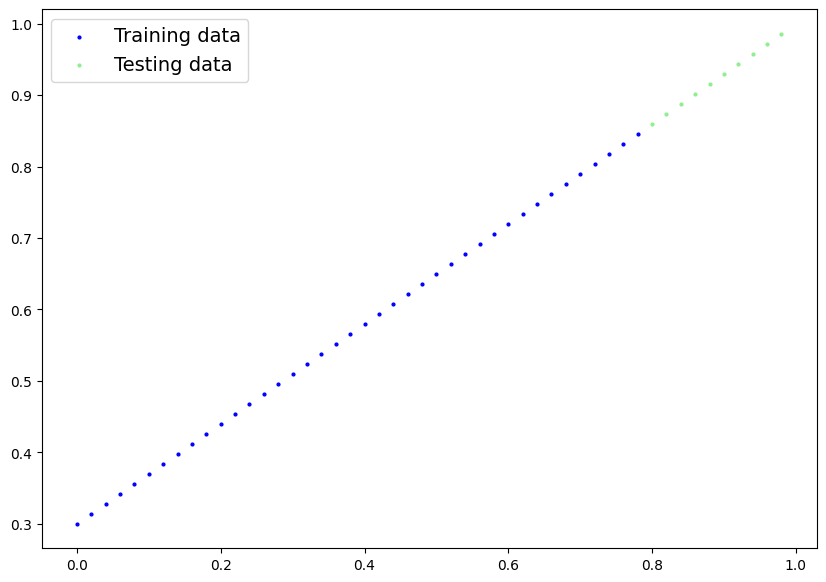

In [19]:
def plot_predictions(train_data=X_train,
                    train_labels=Y_train,
                    test_data=X_test,
                    test_labels=Y_test,
                    predictions=None):
  plt.figure(figsize=(10, 7))

  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="lightgreen", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14})

#CALL
plot_predictions()

In [21]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict(),

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [35]:
# Create loss function
loss_fn = nn.L1Loss() # Loss Function | MAE => Mean Absolute Error

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), #optimize newly created model's parameters
                            lr=0.01) #weight, bias | equal

Text(0.5, 1.0, 'Early train predictions (red = random guessess)')

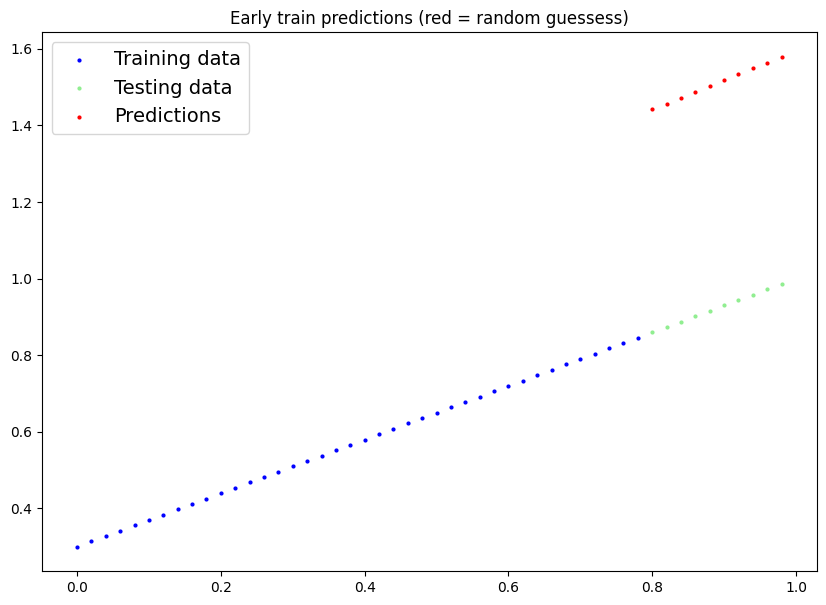

In [26]:
model_1.eval()

with torch.inference_mode():
  y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)
plt.title('Early train predictions (red = random guessess)')

In [38]:
epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_pred = model_1(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    test_pred = model_1(X_test)

    test_loss = loss_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 100 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 200 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 300 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 400 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 500 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 600 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 700 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 800 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 900 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904


In [42]:
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

Text(0.5, 1.0, 'Trained predictions (red = trained predictions)')

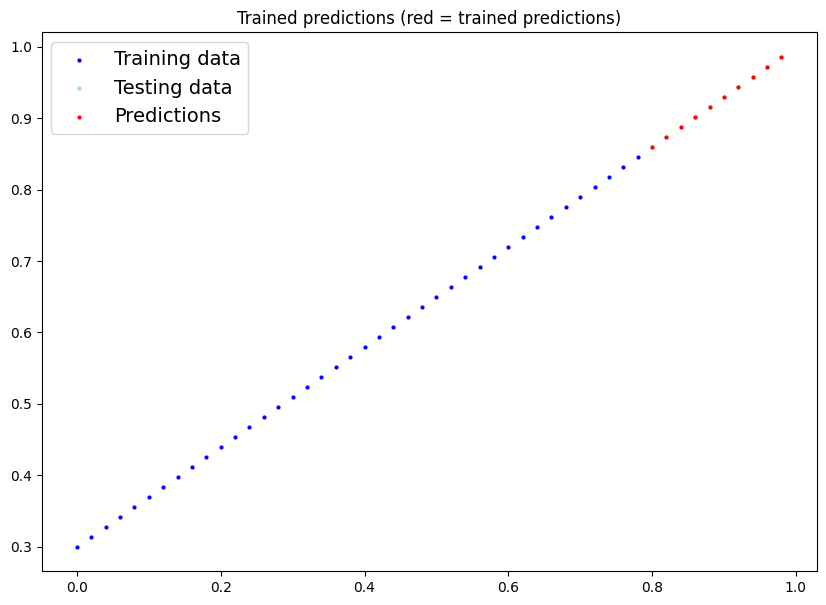

In [44]:
plot_predictions(predictions=y_preds)
plt.title('Trained predictions (red = trained predictions)')

In [46]:
torch.save(model_1.state_dict(), 'trained-model.pth')

In [48]:
loaded_model = LinearRegressionModelV2()
loaded_model.load_state_dict(torch.load('/content/trained-model.pth'))

loaded_model.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)